In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"aydanmemmedova29","key":"600305e879c47f7c58f54907730655cd"}'}

In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d sujaykapadnis/emotion-recognition-dataset

Dataset URL: https://www.kaggle.com/datasets/sujaykapadnis/emotion-recognition-dataset
License(s): CC-BY-NC-SA-4.0


In [ ]:
import zipfile

with zipfile.ZipFile('/content/emotion-recognition-dataset.zip','r') as zip_ref:
  zip_ref.extractall()

In [ ]:
import shutil

shutil.rmtree('/content/dataset/Ahegao')

In [ ]:
import os

for dirpath,dirnames,filenames in os.walk('/content/dataset'):
  print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}.")

There are 5 directories and 0 images in '/content/dataset.
There are 0 directories and 1234 images in '/content/dataset/Surprise.
There are 0 directories and 4027 images in '/content/dataset/Neutral.
There are 0 directories and 3934 images in '/content/dataset/Sad.
There are 0 directories and 1313 images in '/content/dataset/Angry.
There are 0 directories and 3740 images in '/content/dataset/Happy.


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pathlib
import random

def view_random_image(target_dir,target_class):
  target_folder=pathlib.Path(target_dir)/target_class
  random_image=random.choice(os.listdir(target_folder))
  img=mpimg.imread(target_folder/random_image)
  plt.imshow(img)
  plt.axis("off")
  return img.shape

(997, 670, 3)

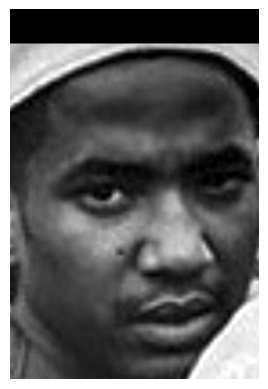

In [ ]:
view_random_image(target_dir='/content/dataset',target_class='Angry')

In [ ]:
import tensorflow as tf
IMG_SIZE=(224,224)

data_path='/content/dataset'

train_data=tf.keras.preprocessing.image_dataset_from_directory(data_path,
                                                               label_mode='categorical',
                                                               image_size=IMG_SIZE,
                                                               subset='training',seed=42,
                                                               validation_split=0.2,crop_to_aspect_ratio=True)
test_data=tf.keras.preprocessing.image_dataset_from_directory(data_path,
                                                              label_mode='categorical',
                                                              image_size=IMG_SIZE,
                                                              subset='validation',
                                                              seed=42,validation_split=0.2,
                                                              crop_to_aspect_ratio=True)


Found 14248 files belonging to 5 classes.
Using 11399 files for training.
Found 14248 files belonging to 5 classes.
Using 2849 files for validation.


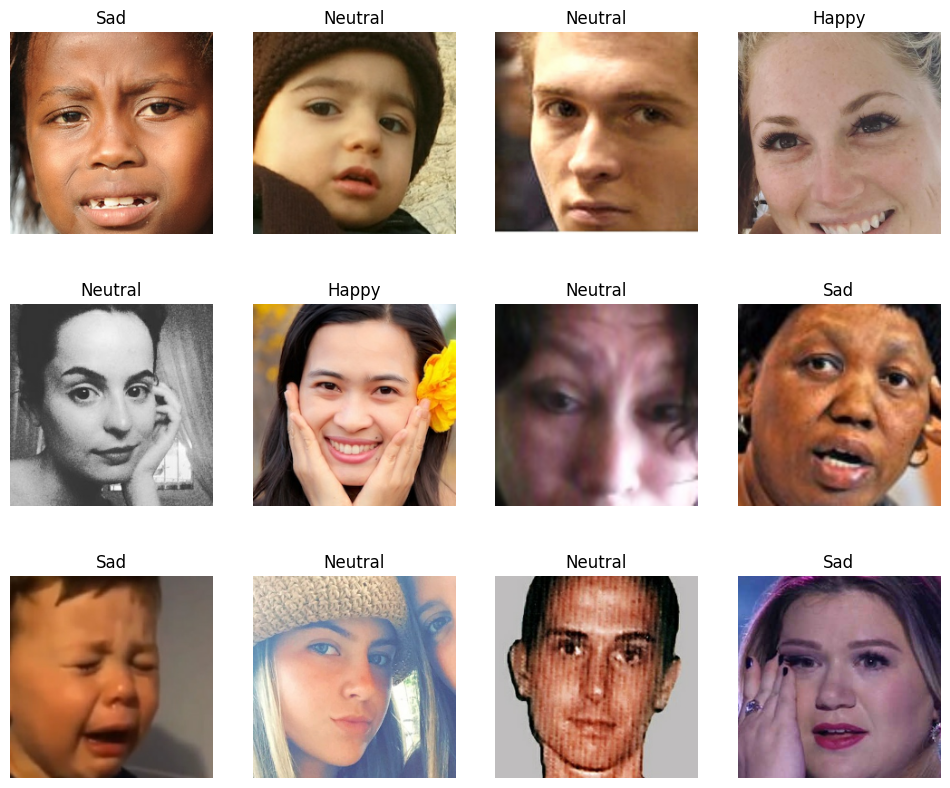

In [ ]:
import numpy as np
class_names=train_data.class_names

plt.figure(figsize=(12,10))

for images,labels in train_data.take(1):
  for i in range(12):
    ax=plt.subplot(3,4,i+1)
    plt.imshow(images[i]/255)
    plt.axis("off")


In [ ]:
model=tf.keras.Sequential([
    tf.keras.layers.Input(shape=(224,224,3)),
    tf.keras.layers.Rescaling(1/255.),
    tf.keras.layers.Conv2D(64,kernel_size=7,strides=3,padding='same',activation='relu',kernel_initializer='he_normal'),
    tf.keras.layers.MaxPool2D(pool_size=2),
    tf.keras.layers.Conv2D(128,kernel_size=3,padding='same',activation='relu',kernel_initializer='he_normal'),
    tf.keras.layers.Conv2D(128,kernel_size=3,padding='same',activation='relu',kernel_initializer='he_normal'),
    tf.keras.layers.MaxPool2D(pool_size=2),
    tf.keras.layers.Conv2D(256,kernel_size=3,padding='same',activation='relu',kernel_initializer='he_normal'),
    tf.keras.layers.Conv2D(256,kernel_size=3,padding='same',activation='relu',kernel_initializer='he_normal'),
    tf.keras.layers.MaxPool2D(pool_size=2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128,activation='relu',kernel_initializer='he_normal'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(64,activation='relu',kernel_initializer='he_normal'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(len(class_names),activation='softmax')

])

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)                │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 75, 75, 64)          │           9,472 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 37, 37, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 37, 37, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 37, 37, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 18, 18, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 18, 18, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 18, 18, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 9, 9, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 20736)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       2,654,336 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 5)                   │             325 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,779,077 (14.42 MB)

 Trainable params: 3,779,077 (14.42 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(loss='categorical_crossentropy',optimizer=tf.keras.optimizers.Adam(),metrics=['accuracy','f1_score'])

In [ ]:
model.fit(train_data,epochs=2,validation_data=test_data)

Epoch 1/2
357/357 ━━━━━━━━━━━━━━━━━━━━ 73s 161ms/step - accuracy: 0.2663 - f1_score: 0.1777 - loss: 1.6056 - val_accuracy: 0.3019 - val_f1_score: 0.1546 - val_loss: 1.4714
Epoch 2/2
357/357 ━━━━━━━━━━━━━━━━━━━━ 59s 125ms/step - accuracy: 0.2821 - f1_score: 0.1828 - loss: 1.4775 - val_accuracy: 0.3141 - val_f1_score: 0.1680 - val_loss: 1.4499


In [ ]:
inputs=tf.keras.Input(shape=(224,224,3))

x=tf.keras.applications.resnet50.preprocess_input(inputs)
base_model=tf.keras.applications.ResNet50(include_top=False,input_tensor=x)
avg=tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
output=tf.keras.layers.Dense(5,activation='softmax')(avg)

model=tf.keras.Model(inputs,output)


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
base_model.trainable=False

In [ ]:
initial_learning_rate=0.01
lr_schedule=tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate,
    decay_steps=357,
    decay_rate=0.96
)

early_stopping=tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

checkpoint_cb=tf.keras.callbacks.ModelCheckpoint(
    'emotion_detector.keras',
    save_best_only=True
)

model.compile(
    loss='categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(lr_schedule),
    metrics=['accuracy','f1_score']
)

history=model.fit(
    train_data,
    validation_data=test_data,
    epochs=30,
    callbacks=[early_stopping,checkpoint_cb]
)

Epoch 1/30
357/357 ━━━━━━━━━━━━━━━━━━━━ 72s 166ms/step - accuracy: 0.4793 - f1_score: 0.4502 - loss: 1.9287 - val_accuracy: 0.6058 - val_f1_score: 0.5952 - val_loss: 1.2377
Epoch 2/30
357/357 ━━━━━━━━━━━━━━━━━━━━ 47s 131ms/step - accuracy: 0.6151 - f1_score: 0.5995 - loss: 1.2492 - val_accuracy: 0.5409 - val_f1_score: 0.5401 - val_loss: 1.5383
Epoch 3/30
357/357 ━━━━━━━━━━━━━━━━━━━━ 83s 134ms/step - accuracy: 0.6605 - f1_score: 0.6535 - loss: 1.0499 - val_accuracy: 0.6269 - val_f1_score: 0.6230 - val_loss: 1.2667
Epoch 4/30
357/357 ━━━━━━━━━━━━━━━━━━━━ 83s 137ms/step - accuracy: 0.6732 - f1_score: 0.6695 - loss: 1.0307 - val_accuracy: 0.6167 - val_f1_score: 0.6145 - val_loss: 1.3412


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


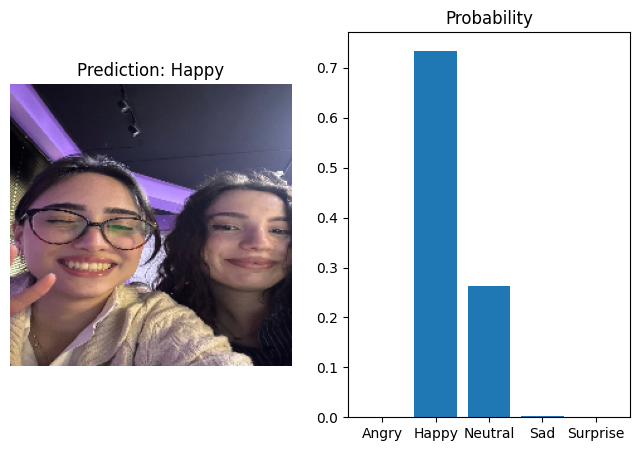

In [ ]:
def pred_and_plot(model,image_path):
  img=mpimg.imread(image_path)
  img=tf.image.resize(img,size=[224,224])
  img=img[tf.newaxis,...]
  pred=model.predict(img)
  plt.figure(figsize=(8,5))
  plt.subplot(1,2,1)
  plt.imshow(img[0]/255)
  plt.title(f"Prediction: {class_names[np.argmax(pred)]}")
  plt.axis(False)
  plt.subplot(1,2,2)
  plt.bar(class_names,pred[0])
  plt.title("Probability")
  plt.show()
pred_and_plot(model,'/content/WhatsApp Image 2025-04-05 at 11.29.51_3b5056d6.jpg')

In [ ]:
data_augementation=tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal_and_vertical'),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom((-0.1, 0.0)),
    tf.keras.layers.GaussianNoise(0.1),
    tf.keras.layers.RandomBrightness(0.2)

])

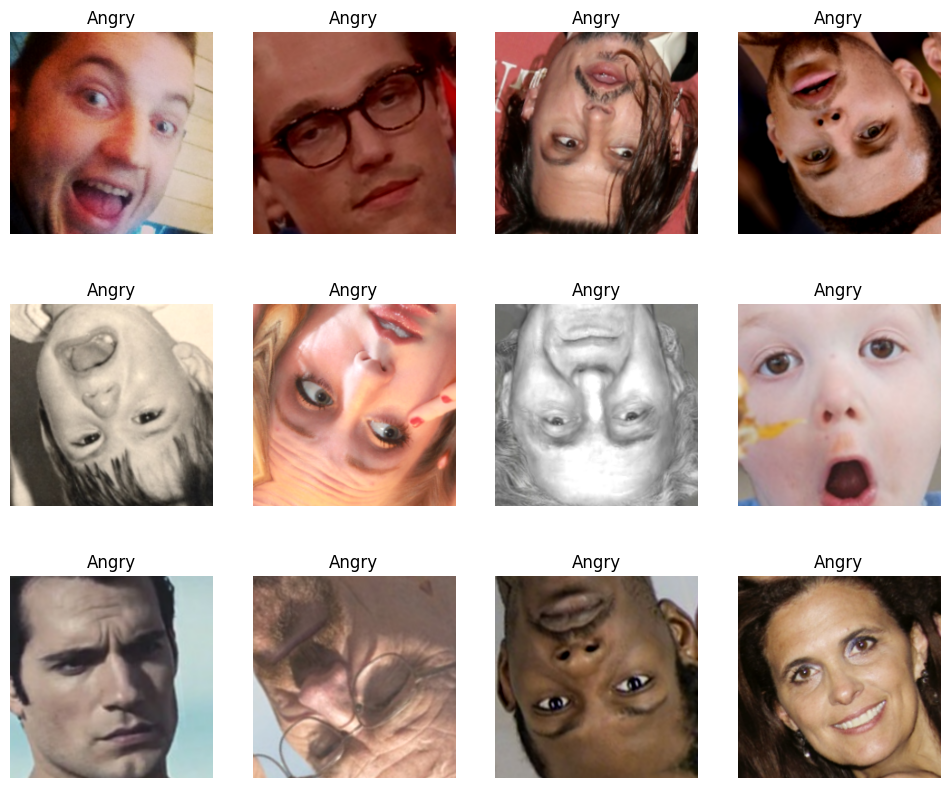

In [ ]:
plt.figure(figsize=(12,10))

for images,labels in train_data.take(1):
  image_augemented=data_augementation(images)
for i in range(12):
  ax=plt.subplot(3,4,i+1)
  plt.imshow(image_augemented[i].numpy().astype('uint8'))
  plt.axis("off")

In [ ]:
inputs=tf.keras.Input(shape=(224,224,3))
X_data=data_augementation(inputs)
x=tf.keras.applications.resnet50.preprocess_input(X_data)
base_model=tf.keras.applications.ResNet50(include_top=False,input_tensor=x)
avg=tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
output=tf.keras.layers.Dense(5,activation='softmax')(avg)

model=tf.keras.Model(inputs,output)

In [ ]:
base_model.trainable=False

In [ ]:
initial_learning_rate=0.001
lr_schedule=tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate,
    decay_steps=357,
    decay_rate=0.96
)

early_stopping=tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

checkpoint_cb=tf.keras.callbacks.ModelCheckpoint(
    'emotion_detector.keras',
    save_best_only=True
)

model.compile(
    loss='categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(lr_schedule),
    metrics=['accuracy','f1_score']
)

history=model.fit(
    train_data,
    validation_data=test_data,
    epochs=30,
    callbacks=[early_stopping,checkpoint_cb]
)

Epoch 1/30
357/357 ━━━━━━━━━━━━━━━━━━━━ 89s 222ms/step - accuracy: 0.4274 - f1_score: 0.3831 - loss: 1.3605 - val_accuracy: 0.5620 - val_f1_score: 0.5133 - val_loss: 1.0978
Epoch 2/30
357/357 ━━━━━━━━━━━━━━━━━━━━ 70s 197ms/step - accuracy: 0.5612 - f1_score: 0.5340 - loss: 1.0709 - val_accuracy: 0.5690 - val_f1_score: 0.5414 - val_loss: 1.0630
Epoch 3/30
357/357 ━━━━━━━━━━━━━━━━━━━━ 82s 197ms/step - accuracy: 0.6010 - f1_score: 0.5789 - loss: 0.9810 - val_accuracy: 0.6111 - val_f1_score: 0.5741 - val_loss: 0.9798
Epoch 4/30
357/357 ━━━━━━━━━━━━━━━━━━━━ 70s 196ms/step - accuracy: 0.6050 - f1_score: 0.5897 - loss: 0.9607 - val_accuracy: 0.6230 - val_f1_score: 0.5726 - val_loss: 0.9681
Epoch 5/30
357/357 ━━━━━━━━━━━━━━━━━━━━ 77s 181ms/step - accuracy: 0.6356 - f1_score: 0.6168 - loss: 0.9192 - val_accuracy: 0.6076 - val_f1_score: 0.5675 - val_loss: 0.9664
Epoch 6/30
357/357 ━━━━━━━━━━━━━━━━━━━━ 77s 169ms/step - accuracy: 0.6357 - f1_score: 0.6168 - loss: 0.9012 - val_accuracy: 0.5992 - va

In [ ]:
from tensorflow.keras.metrics import F1Score


data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom((-0.5, 0.0)),
    tf.keras.layers.RandomBrightness(0.2),
    tf.keras.layers.GaussianNoise(0.1),
])


inputs = tf.keras.Input(shape=(224, 224, 3))
X_data = data_augmentation(inputs)
x = tf.keras.applications.resnet50.preprocess_input(X_data)
base_model = tf.keras.applications.ResNet50(include_top=False, input_tensor=x)
avg = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
output = tf.keras.layers.Dense(5, activation='softmax')(avg)
model = tf.keras.Model(inputs, output)


base_model.trainable = True
for layer in base_model.layers[:-10]:
    layer.trainable = False


initial_learning_rate = 0.001
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate,
    decay_steps=357,
    decay_rate=0.96
)


early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint('emotion_detector.keras', save_best_only=True)

model.compile(
    loss='categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(lr_schedule),
    metrics=['accuracy', F1Score()]
)

history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=30,
    callbacks=[early_stopping, checkpoint_cb]
)

Epoch 1/30
357/357 ━━━━━━━━━━━━━━━━━━━━ 92s 231ms/step - accuracy: 0.5300 - f1_score: 0.4844 - loss: 1.2199 - val_accuracy: 0.6588 - val_f1_score: 0.6488 - val_loss: 0.8518
Epoch 2/30
357/357 ━━━━━━━━━━━━━━━━━━━━ 129s 197ms/step - accuracy: 0.6742 - f1_score: 0.6531 - loss: 0.8221 - val_accuracy: 0.6750 - val_f1_score: 0.6638 - val_loss: 0.8151
Epoch 3/30
357/357 ━━━━━━━━━━━━━━━━━━━━ 92s 224ms/step - accuracy: 0.7003 - f1_score: 0.6817 - loss: 0.7451 - val_accuracy: 0.6939 - val_f1_score: 0.6793 - val_loss: 0.7867
Epoch 4/30
357/357 ━━━━━━━━━━━━━━━━━━━━ 74s 208ms/step - accuracy: 0.7176 - f1_score: 0.7035 - loss: 0.6992 - val_accuracy: 0.6873 - val_f1_score: 0.6728 - val_loss: 0.8154
Epoch 5/30
357/357 ━━━━━━━━━━━━━━━━━━━━ 66s 184ms/step - accuracy: 0.7313 - f1_score: 0.7177 - loss: 0.6628 - val_accuracy: 0.7188 - val_f1_score: 0.7094 - val_loss: 0.7115
Epoch 6/30
357/357 ━━━━━━━━━━━━━━━━━━━━ 64s 179ms/step - accuracy: 0.7471 - f1_score: 0.7358 - loss: 0.6280 - val_accuracy: 0.7094 - v

In [ ]:
from tensorflow.keras.metrics import F1Score


data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom((-0.7, 0.0)),
    tf.keras.layers.RandomBrightness(0.2),
    tf.keras.layers.GaussianNoise(0.1),
])


inputs = tf.keras.Input(shape=(224, 224, 3))
X_data = data_augmentation(inputs)
x = tf.keras.applications.resnet50.preprocess_input(X_data)
base_model = tf.keras.applications.ResNet50(include_top=False, input_tensor=x)
avg = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
output = tf.keras.layers.Dense(5, activation='softmax')(avg)
model = tf.keras.Model(inputs, output)


base_model.trainable = True
for layer in base_model.layers[:-15]:
    layer.trainable = False

initial_learning_rate = 0.001
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate,
    decay_steps=357,
    decay_rate=0.96
)


early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint('emotion_detector.keras', save_best_only=True)


model.compile(
    loss='categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(lr_schedule),
    metrics=['accuracy', F1Score()]
)


history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=30,
    callbacks=[early_stopping, checkpoint_cb]
)

Epoch 1/30
357/357 ━━━━━━━━━━━━━━━━━━━━ 86s 212ms/step - accuracy: 0.4977 - f1_score: 0.4480 - loss: 1.2955 - val_accuracy: 0.6174 - val_f1_score: 0.5928 - val_loss: 0.9431
Epoch 2/30
357/357 ━━━━━━━━━━━━━━━━━━━━ 73s 204ms/step - accuracy: 0.6362 - f1_score: 0.6053 - loss: 0.8984 - val_accuracy: 0.6648 - val_f1_score: 0.6085 - val_loss: 0.8481
Epoch 3/30
357/357 ━━━━━━━━━━━━━━━━━━━━ 91s 231ms/step - accuracy: 0.6651 - f1_score: 0.6420 - loss: 0.8297 - val_accuracy: 0.6732 - val_f1_score: 0.6428 - val_loss: 0.8164
Epoch 4/30
357/357 ━━━━━━━━━━━━━━━━━━━━ 135s 213ms/step - accuracy: 0.6875 - f1_score: 0.6669 - loss: 0.7750 - val_accuracy: 0.6237 - val_f1_score: 0.6119 - val_loss: 0.8775
Epoch 5/30
357/357 ━━━━━━━━━━━━━━━━━━━━ 74s 206ms/step - accuracy: 0.7048 - f1_score: 0.6897 - loss: 0.7291 - val_accuracy: 0.7234 - val_f1_score: 0.7088 - val_loss: 0.6928
Epoch 6/30
357/357 ━━━━━━━━━━━━━━━━━━━━ 84s 212ms/step - accuracy: 0.7197 - f1_score: 0.6949 - loss: 0.7100 - val_accuracy: 0.7139 - v